# Notebook 00d — Inspect COT Data

**Purpose:** Inspect CFTC Commitment of Traders positioning data for EUR futures.

## What is COT?

Weekly data on positioning of **large speculators (Non-Commercial traders)** in EUR futures. This is **behavioral data** — it shows what "smart money" is doing.

## Columns Inspected

| Column | Meaning |
|---|---|
| eur_noncomm_long | Long positions by large speculators |
| eur_noncomm_short | Short positions by large speculators |
| eur_net_position | Net = long − short (positive = bullish EUR) |
| eur_net_position_pct | Normalized net [-1, +1] |

## Economic Logic

- **Extreme Net Long** → bullish exhausted → potential reversal down
- **Extreme Net Short** → bearish exhausted → potential reversal up

This is a **contrarian signal** at extremes.

**Output:** Charts saved to `figures/data_inspection/cot/`

---

**Author:** Dong Cong Gia Khang  
**Date:** May 2026

## 1. Setup

In [6]:
"""
Setup imports and paths.
"""
import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_project_root(marker=".env"):
    """Find project root by looking for a marker file."""
    current = Path.cwd()
    for parent in [current] + list(current.parents):
        if (parent / marker).exists():
            return parent
    raise RuntimeError(f"Could not find {marker}")


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))

RAW_DIR = PROJECT_ROOT / "data" / "raw" / "cot"
FIG_DIR = PROJECT_ROOT / "figures" / "data_inspection" / "cot"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["savefig.dpi"] = 120
plt.rcParams["savefig.bbox"] = "tight"

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data:     {RAW_DIR}")
print(f"Figures:      {FIG_DIR}")

Project root: d:\Final Project 2
Raw data:     d:\Final Project 2\data\raw\cot
Figures:      d:\Final Project 2\figures\data_inspection\cot


## 2. Load COT Data

The COT file has 4 columns. We load it once, then inspect each column.

In [7]:
"""
Load COT data and show overview.

Note: CFTC publishes TWO EUR contracts per week:
  - EURO FX (main, large volume)
  - EURO FX, CROSS RATES (minor, small volume)
We aggregate them by date (sum positions, mean for normalized %)
to get total EUR speculator exposure — same logic as build_dataset.py.
"""
cot_raw = pd.read_csv(RAW_DIR / "eur_cot.csv")
cot_raw["date"] = pd.to_datetime(cot_raw["date"])

print(f"Raw shape (before aggregation): {cot_raw.shape}")
print(f"Unique dates: {cot_raw['date'].nunique()}")
print(f"Rows per date: {len(cot_raw)/cot_raw['date'].nunique():.2f} "
      f"(CFTC publishes 2 EUR contracts)")

# Aggregate duplicate dates (2 contracts -> 1 total per date)
cot = cot_raw.groupby("date", as_index=False).agg({
    "eur_noncomm_long": "sum",
    "eur_noncomm_short": "sum",
    "eur_net_position": "sum",
    "eur_net_position_pct": "mean",
})
cot = cot.sort_values("date").reset_index(drop=True)

print(f"\nAfter aggregation: {cot.shape}")
print(f"Columns: {list(cot.columns)}")
print(f"Date range: {cot['date'].min().date()} -> {cot['date'].max().date()}")
print(f"\nFirst 3 rows:")
print(cot.head(3).to_string(index=False))
print(f"\nLast 3 rows:")
print(cot.tail(3).to_string(index=False))

Raw shape (before aggregation): (1581, 5)
Unique dates: 852
Rows per date: 1.86 (CFTC publishes 2 EUR contracts)

After aggregation: (852, 5)
Columns: ['date', 'eur_noncomm_long', 'eur_noncomm_short', 'eur_net_position', 'eur_net_position_pct']
Date range: 2010-01-05 -> 2026-04-28

First 3 rows:
      date  eur_noncomm_long  eur_noncomm_short  eur_net_position  eur_net_position_pct
2010-01-05             37229              73017            -35788             -0.324619
2010-01-12             36186              54103            -17917             -0.198441
2010-01-19             34186              59468            -25282             -0.269951

Last 3 rows:
      date  eur_noncomm_long  eur_noncomm_short  eur_net_position  eur_net_position_pct
2026-04-14            225434             198218             27216              0.060674
2026-04-21            228777             187377             41400              0.037187
2026-04-28            228123             192776             35347        

## 3. Inspection Helper Function

In [8]:
"""
Helper to inspect one COT column.
"""
def inspect_cot_column(col, description):
    """Inspect a single COT column. Returns summary dict."""
    series = cot[col].dropna()

    print(f"\n{'='*70}")
    print(f"  {col}")
    print(f"{'='*70}")
    print(f"Description: {description}")
    print(f"Valid values: {len(series)}")
    print(f"\nStatistics:")
    print(f"  mean:   {series.mean():14.4f}")
    print(f"  std:    {series.std():14.4f}")
    print(f"  min:    {series.min():14.4f}")
    print(f"  max:    {series.max():14.4f}")
    print(f"  latest: {series.iloc[-1]:14.4f}")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))

    ax1.plot(cot["date"], cot[col], color="purple", linewidth=0.8)
    ax1.axhline(y=0, color="black", linewidth=0.5)
    ax1.set_title(f"{col} — Time Series", fontsize=12, fontweight="bold")
    ax1.set_xlabel("Date")
    ax1.set_ylabel(col)
    ax1.grid(True, alpha=0.3)

    ax2.hist(series, bins=50, color="mediumpurple", alpha=0.7, edgecolor="white")
    ax2.axvline(series.mean(), color="red", linestyle="--", linewidth=1,
                label=f"mean={series.mean():.2f}")
    ax2.axvline(series.median(), color="green", linestyle="--", linewidth=1,
                label=f"median={series.median():.2f}")
    ax2.set_title(f"{col} — Distribution", fontsize=12, fontweight="bold")
    ax2.set_xlabel(col)
    ax2.set_ylabel("Frequency")
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    out_path = FIG_DIR / f"{col}.png"
    plt.savefig(out_path)
    plt.show()
    print(f"\nSaved: {out_path.relative_to(PROJECT_ROOT)}")

    return {
        "column": col,
        "valid": len(series),
        "mean": round(series.mean(), 4),
        "std": round(series.std(), 4),
        "min": round(series.min(), 4),
        "max": round(series.max(), 4),
    }


print("Helper function defined")

Helper function defined


## 4. Inspect All 4 COT Columns


  eur_noncomm_long
Description: EUR futures long positions by Non-Commercial traders (large speculators).
Valid values: 852

Statistics:
  mean:      148972.4648
  std:        78103.0617
  min:        17040.0000
  max:       332257.0000
  latest:    228123.0000


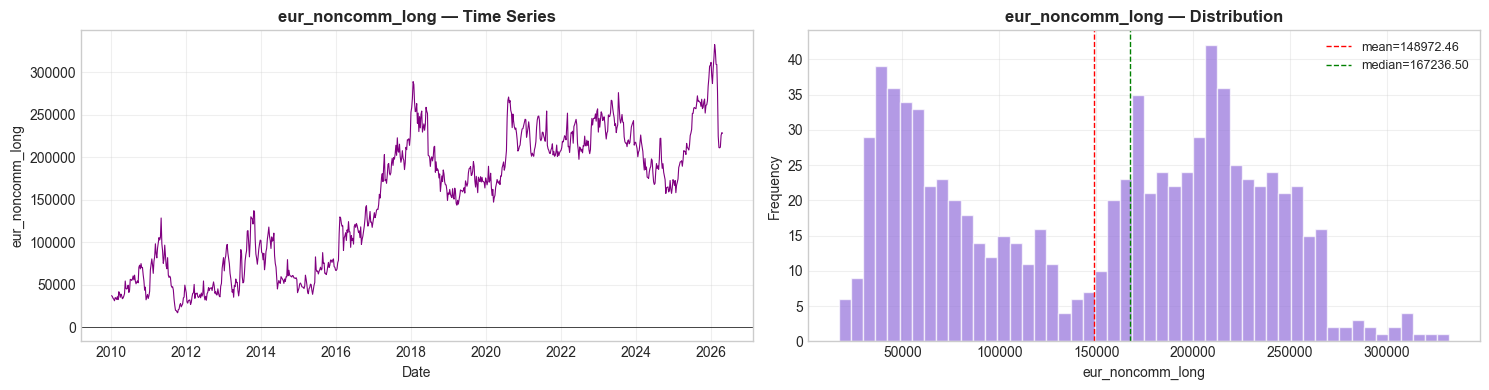


Saved: figures\data_inspection\cot\eur_noncomm_long.png

  eur_noncomm_short
Description: EUR futures short positions by Non-Commercial traders.
Valid values: 852

Statistics:
  mean:      145870.9413
  std:        61744.5022
  min:        24736.0000
  max:       276646.0000
  latest:    192776.0000


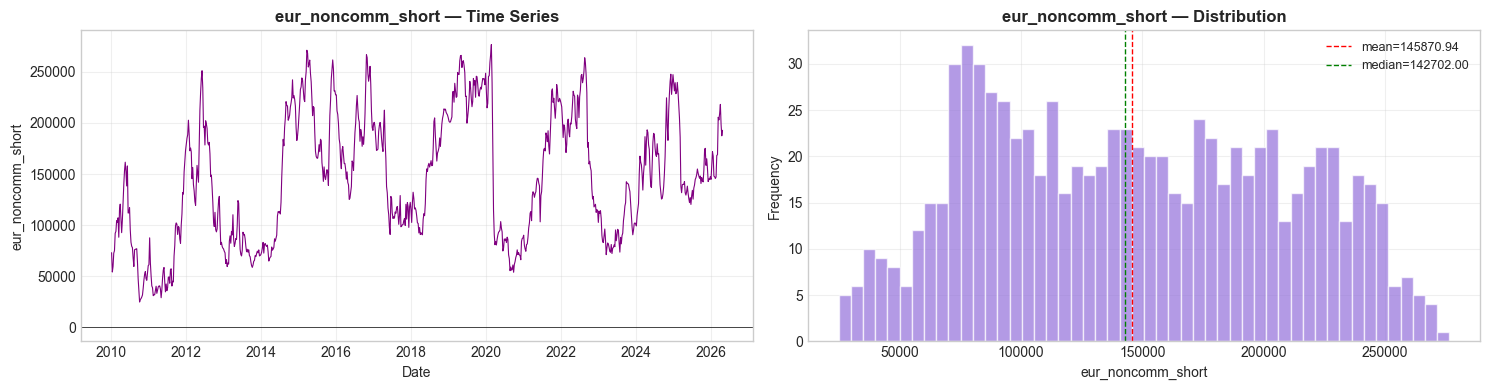


Saved: figures\data_inspection\cot\eur_noncomm_short.png

  eur_net_position
Description: Net position = long - short. Positive = net bullish EUR.
Valid values: 852

Statistics:
  mean:        3101.5235
  std:        96136.0527
  min:      -226560.0000
  max:       210988.0000
  latest:     35347.0000


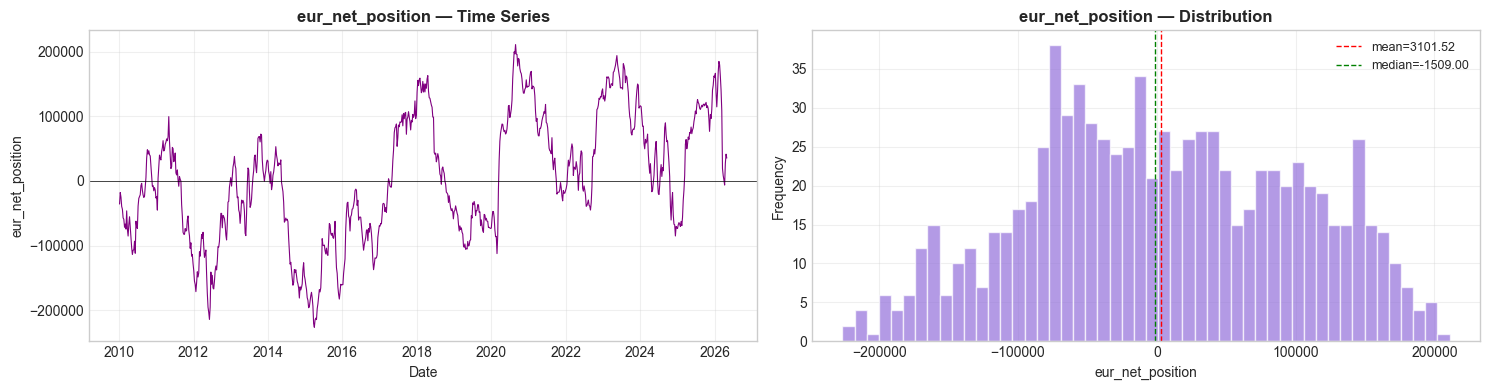


Saved: figures\data_inspection\cot\eur_net_position.png

  eur_net_position_pct
Description: Normalized net position [-1, +1]. Removes dependency on total volume.
Valid values: 852

Statistics:
  mean:          -0.0314
  std:            0.3408
  min:           -0.7452
  max:            0.7551
  latest:         0.0190


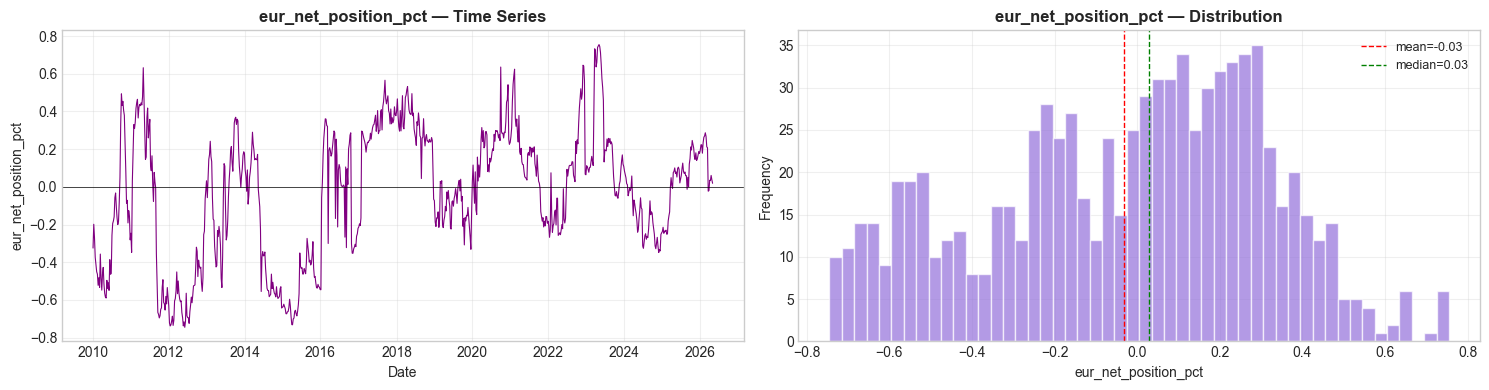


Saved: figures\data_inspection\cot\eur_net_position_pct.png


In [9]:
cot_summaries = []

cot_summaries.append(inspect_cot_column(
    "eur_noncomm_long",
    "EUR futures long positions by Non-Commercial traders (large speculators)."))

cot_summaries.append(inspect_cot_column(
    "eur_noncomm_short",
    "EUR futures short positions by Non-Commercial traders."))

cot_summaries.append(inspect_cot_column(
    "eur_net_position",
    "Net position = long - short. Positive = net bullish EUR."))

cot_summaries.append(inspect_cot_column(
    "eur_net_position_pct",
    "Normalized net position [-1, +1]. Removes dependency on total volume."))

## 5. Summary

In [10]:
"""
Summary table of all 4 COT columns.
"""
summary_df = pd.DataFrame(cot_summaries)

print("COT COLUMNS SUMMARY")
print("=" * 80)
print(summary_df.to_string(index=False))

print(f"\nCharts saved in {FIG_DIR.relative_to(PROJECT_ROOT)}:")
for png in sorted(FIG_DIR.glob("*.png")):
    print(f"  - {png.name}")

COT COLUMNS SUMMARY
              column  valid        mean        std          min         max
    eur_noncomm_long    852 148972.4648 78103.0617   17040.0000 332257.0000
   eur_noncomm_short    852 145870.9413 61744.5022   24736.0000 276646.0000
    eur_net_position    852   3101.5235 96136.0527 -226560.0000 210988.0000
eur_net_position_pct    852     -0.0314     0.3408      -0.7452      0.7551

Charts saved in figures\data_inspection\cot:
  - eur_net_position.png
  - eur_net_position_pct.png
  - eur_noncomm_long.png
  - eur_noncomm_short.png


## Conclusion

### COT Data Summary

 Inspected all **4 COT columns**  
 Charts saved to `figures/data_inspection/cot/`

### Key Observations

- **Net positioning** swings widely between extreme long and extreme short
- **Normalized %** gives a bounded signal [-1, +1], better for modeling
- Positioning extremes often precede reversals (contrarian signal)

### Frequency Note

COT is **weekly** data — it will be forward-filled when merged into the daily master dataset.

### All Inspection Complete

This completes inspection of all 4 data sources:
- 00a — yfinance (4 series)
- 00b — FRED (13 series)
- 00c — ECB (4 series)
- 00d — COT (4 columns)

**Next:** `01_data_quality.ipynb` builds and validates the master dataset (with merge logic explained).